In [1]:
import numpy as np
import mnist_reader

from sklearn.svm import SVC, LinearSVC
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_validate
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import pandas as pd
import matplotlib.pyplot as plt


def binary_classification(X, y, c0=5, c1=7):
    mask = np.isin(y, [c0, c1])
    X_binary = X[mask]
    y_binary = np.where(y[mask] == c1, 1, 0).astype(np.int64)

    return X_binary, y_binary


rng = np.random.default_rng(123)
X_train, y_train = mnist_reader.load_mnist("data", kind="train")
X_test, y_test = mnist_reader.load_mnist("data", kind="t10k")
X_train, y_train = binary_classification(X_train, y_train)
X_test, y_test = binary_classification(X_test, y_test)
print("Train shape:", X_train.shape)


samples = 3000     
selected = []
for class_label in (0, 1):
    class_idx = np.where(y_train == class_label)[0]
    sampled  = rng.choice(class_idx, size=samples, replace=False)
    selected.append(sampled)
selected = np.concatenate(selected)
rng.shuffle(selected)

X_train = X_train[selected]
y_train = y_train[selected]
print(f"Now, reduced train shape to {X_train.shape}  (each class contains {samples} samples)")

# Rescaling with dividing
X_train = X_train / 255
X_test = X_test / 255

# Only rescaling for Gaussian kernel for better result
train_norms = np.linalg.norm(X_train, axis=1, keepdims=True)
test_norms = np.linalg.norm(X_test, axis=1, keepdims=True)
X_train_unit = X_train / np.maximum(train_norms, 1e-12)
X_test_unit = X_test / np.maximum(test_norms, 1e-12)

p_flip = 0.2
y_train_clean = y_train.copy()
flip_mask = rng.random(len(y_train_clean)) < p_flip
print(f"Label noise probability is {p_flip}, the total number of flip is {flip_mask.sum()}, and approximately rate of actual flip is {flip_mask.mean():.4f}")

y_train_noisy = np.where(flip_mask, 1 - y_train_clean, y_train_clean)
print(f"The noisy of train class: {np.bincount(y_train_noisy)}")

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
C_grid = np.logspace(-2, 2, 10, base=10); print("The regularization parameter C is: \n", np.round(C_grid, 3))
gamma_grid = np.logspace(-4, 2, 10, base=8); print("The gamma scale parameter is: \n", np.round(gamma_grid, 3))

Train shape: (12000, 784)
Now, reduced train shape to (6000, 784)  (each class contains 3000 samples)
Label noise probability is 0.2, the total number of flip is 1174, and approximately rate of actual flip is 0.1957
The noisy of train class: [3030 2970]
The regularization parameter C is: 
 [1.0000e-02 2.8000e-02 7.7000e-02 2.1500e-01 5.9900e-01 1.6680e+00
 4.6420e+00 1.2915e+01 3.5938e+01 1.0000e+02]
The gamma scale parameter is: 
 [0.0e+00 1.0e-03 4.0e-03 1.6e-02 6.2e-02 2.5e-01 1.0e+00 4.0e+00 1.6e+01
 6.4e+01]


## Part 1 — Linear SVM

In [9]:
final_results, cv_results = [], []

for C in C_grid:
    model = LinearSVC(C=float(C), dual=False, random_state=123)
    scores = cross_validate(model, X_train, y_train_noisy, cv=skf, scoring='accuracy', return_train_score=True, n_jobs=-1)

    cv_results.append({"C": float(C), 
                       "mean_validation_accuracy": float(scores["test_score"].mean()), 
                       "mean_train_error": float(1 - scores["train_score"].mean()), 
                       "mean_validation_error": float(1 - scores["test_score"].mean()), 
                       "validation_error_std": float(scores["test_score"].std())})

cv_results = pd.DataFrame(cv_results)
best_index = cv_results["mean_validation_error"].idxmin()
best = cv_results.loc[best_index]
best_C = best["C"]; best_validation_error = best["mean_validation_error"]
print(f"The best C of linear SVM at {best_C:.4g}, and the mean validation error of the C is {best_validation_error:.4f}")

for C in C_grid:
    model = LinearSVC(C=float(C), dual=False, random_state=123)
    model.fit(X_train, y_train_noisy)
    train_error_noisy = 1 - accuracy_score(y_train_noisy, model.predict(X_train))
    train_error_clean = 1 - accuracy_score(y_train_clean, model.predict(X_train))
    test_error = 1 - accuracy_score(y_test, model.predict(X_test))

    final_results.append({"C": float(C), 
                          "train_error_noisy": float(train_error_noisy), 
                          "train_error_clean": float(train_error_clean), 
                          "test_error": float(test_error)})

final_results = pd.DataFrame(final_results)

The best C of linear SVM at 0.01, and the mean validation error of the C is 0.2355


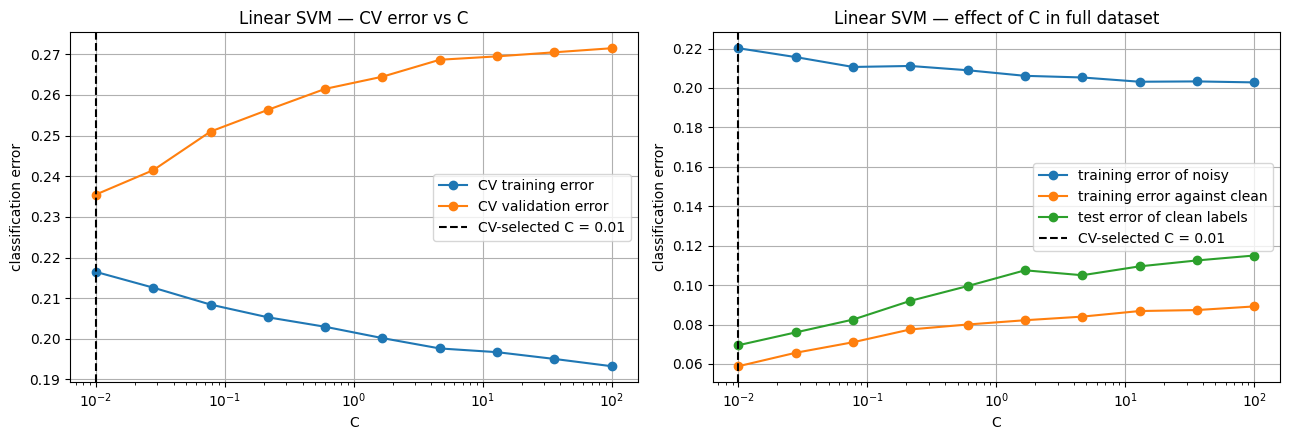

Selected C: 0.01, the noisy training accuracy is 0.7798, and the clean test accuracy: 0.9305 and the error is 0.0695


In [10]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

ax[0].semilogx(cv_results["C"], cv_results["mean_train_error"], marker="o", label="CV training error")
ax[0].semilogx(cv_results["C"], cv_results["mean_validation_error"], marker="o", label="CV validation error")
ax[0].axvline(best_C, linestyle='--', color='k', label=f'CV-selected C = {best_C:.2g}')
ax[0].set(xlabel='C', ylabel='classification error', title='Linear SVM — CV error vs C')
ax[0].legend(); ax[0].grid(True)

ax[1].semilogx(final_results["C"], final_results["train_error_noisy"], marker="o", label="training error of noisy")
ax[1].semilogx(final_results["C"], final_results["train_error_clean"], marker="o", label="training error against clean")
ax[1].semilogx(final_results["C"], final_results["test_error"], marker="o", label="test error of clean labels")
ax[1].axvline(best_C, ls='--', color='k', label=f'CV-selected C = {best_C:.2g}')
ax[1].set(xlabel='C', ylabel='classification error', title='Linear SVM — effect of C in full dataset')
ax[1].legend(); ax[1].grid(True)

plt.tight_layout(); plt.savefig('linear svm errors.png', dpi=800, bbox_inches='tight'); plt.show()


final_lin = LinearSVC(C=best_C, dual=False, random_state=123)
final_lin.fit(X_train, y_train_noisy)
best_train_accuracy = final_lin.score(X_train, y_train_noisy)
best_test_accuracy = final_lin.score(X_test, y_test)
lin_test_error = 1 - best_test_accuracy
print(f"Selected C: {best_C}, the noisy training accuracy is {best_train_accuracy:.4f}, and the clean test accuracy: {best_test_accuracy:.4f} and the error is {lin_test_error:.4f}")

## Part 2 — RBF (Gaussian) SVM


In [11]:
cv_results = []

for G in gamma_grid:
    for C in C_grid:
        model = SVC(kernel="rbf", C=float(C), gamma=float(G))
        scores = cross_validate(model, X_train_unit, y_train_noisy, cv=skf, scoring="accuracy", return_train_score=True, n_jobs=-1)

        cv_results.append({"gamma": float(G), "C": float(C), 
                           "mean_validation_accuracy": float(scores["test_score"].mean()),
                           "mean_train_error": float(1 - scores["train_score"].mean()),
                           "mean_validation_error": float(1 - scores["test_score"].mean()), 
                           "validation_error_std": float(scores["test_score"].std())})
        
cv_results = pd.DataFrame(cv_results)

tuned_per_gamma = (cv_results.loc[cv_results.groupby("gamma")["mean_validation_error"].idxmin()].sort_values("gamma").reset_index(drop=True))
print('Tuned (gamma, C_gamma) pairs: \n', tuned_per_gamma[['gamma', 'C', "mean_validation_error"]])

best_row = tuned_per_gamma.loc[tuned_per_gamma["mean_validation_error"].idxmin()]
best_gamma = float(best_row['gamma'])
best_C = float(best_row['C'])
print(f'Best (gamma, C) by CV: gamma = {best_gamma:.4g}, C={best_C:.4g}, CV error = {best_row["mean_validation_error"]:.4f}')

Tuned (gamma, C_gamma) pairs: 
        gamma           C  mean_validation_error
0   0.000244  100.000000               0.244333
1   0.000977  100.000000               0.232000
2   0.003906  100.000000               0.229833
3   0.015625   35.938137               0.229000
4   0.062500  100.000000               0.224833
5   0.250000   12.915497               0.219500
6   1.000000    1.668101               0.216500
7   4.000000    0.599484               0.216333
8  16.000000    1.668101               0.278167
9  64.000000    1.668101               0.429333
Best (gamma, C) by CV: gamma = 4, C=0.5995, CV error = 0.2163


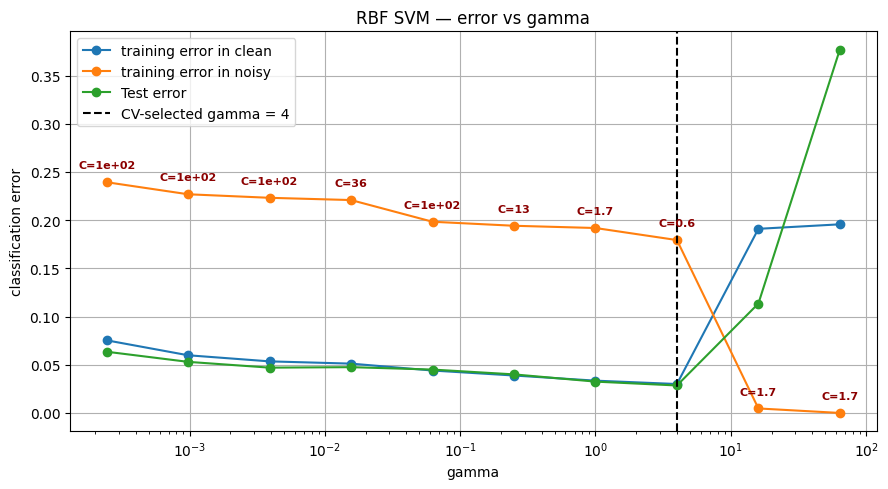

The best of gamma selected on RBF SVM is 4, C is 0.5995, train error is 0.1793, and test error is 0.0285


In [12]:
final_results = []

for _, r in tuned_per_gamma.iterrows():
    G, C = float(r['gamma']), float(r['C'])
    model = SVC(kernel='rbf', C=C, gamma=G)
    model.fit(X_train_unit, y_train_noisy)
    train_noisy_error = 1 - accuracy_score(y_train_noisy, model.predict(X_train_unit))
    train_clean_error = 1 - accuracy_score(y_train_clean, model.predict(X_train_unit))
    test_error = 1 - accuracy_score(y_test, model.predict(X_test_unit))
    final_results.append({'gamma': G, 'C': C,
                          'clean_train_error': train_clean_error,
                          'noisy_train_error': train_noisy_error,
                          'test_error': test_error})

final_results = pd.DataFrame(final_results)

plt.figure(figsize=(9, 5))
plt.semilogx(final_results['gamma'], final_results['clean_train_error'], 'o-', label='training error in clean')
plt.semilogx(final_results['gamma'], final_results['noisy_train_error'], 'o-', label='training error in noisy')
plt.semilogx(final_results['gamma'], final_results['test_error'], 'o-', label='Test error')

for x, y, c in zip(final_results['gamma'], final_results['noisy_train_error'], final_results['C']):
    plt.annotate(f'C={c:.2g}', (x, y), textcoords='offset points', xytext=(0, 10), fontsize=8, color='darkred', ha='center', fontweight='bold')
    
plt.axvline(best_gamma, ls='--', color='k', label=f'CV-selected gamma = {best_gamma:.3g}')
plt.xlabel('gamma')
plt.ylabel('classification error')
plt.title('RBF SVM — error vs gamma')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('rbf svm errors.png', dpi=800, bbox_inches='tight');
plt.show()


final_rbf = SVC(kernel='rbf', C=best_C, gamma=best_gamma)
final_rbf.fit(X_train_unit, y_train_noisy)
rbf_train_error = 1 - accuracy_score(y_train_noisy, final_rbf.predict(X_train_unit))
rbf_test_error = 1 - accuracy_score(y_test, final_rbf.predict(X_test_unit))
print(f"The best of gamma selected on RBF SVM is {best_gamma:.4g}, C is {best_C:.4g}, train error is {rbf_train_error:.4f}, and test error is {rbf_test_error:.4f}")

## Part 3 — Neural network


In [5]:
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)

nn_configs = [
    {"hidden_layer_sizes": (32,), "activation": "relu", "alpha": 1e-4},
    {"hidden_layer_sizes": (64,), "activation": "relu", "alpha": 1e-4},
    {"hidden_layer_sizes": (32,), "activation": "tanh", "alpha": 1e-4},
    {"hidden_layer_sizes": (64,), "activation": "tanh", "alpha": 1e-4},
    {"hidden_layer_sizes": (128,), "activation": "tanh", "alpha": 1e-4},
    {"hidden_layer_sizes": (32,), "activation": "logistic", "alpha": 1e-4},
    {"hidden_layer_sizes": (64,), "activation": "logistic", "alpha": 1e-4},
    {"hidden_layer_sizes": (32, 64), "activation": "relu", "alpha": 1e-4},
    {"hidden_layer_sizes": (64, 128), "activation": "relu", "alpha": 1e-4},
    {"hidden_layer_sizes": (64, 32), "activation": "relu", "alpha": 1e-4},
    {"hidden_layer_sizes": (128, 64), "activation": "relu", "alpha": 1e-4},
    {"hidden_layer_sizes": (32,), "activation": "relu", "alpha": 1e-2},
    {"hidden_layer_sizes": (32,), "activation": "relu", "alpha": 1e-1},
    {"hidden_layer_sizes": (32,), "activation": "relu", "alpha": 1e-0},
    {"hidden_layer_sizes": (32,), "activation": "relu", "alpha": 1e-5}]


nn_results = []
for cfg in nn_configs:
    model = MLPClassifier(solver="adam", random_state=123, **cfg)
    scores = cross_validate(model, X_train, y_train_noisy, cv=skf, scoring="accuracy", return_train_score=True, n_jobs=-1)
    validation_error = 1 - scores['test_score'].mean() 
    
    nn_results.append({**cfg, "mean_validation_accuracy": float(scores["test_score"].mean()),
                       "mean_train_error": float(1 - scores["train_score"].mean()),
                       "mean_validation_error": float(validation_error), 
                       "validation_error_std": float(scores["test_score"].std())})
    print(f"[NN] layers={str(cfg["hidden_layer_sizes"]):<10s}, act={cfg["activation"]:<8s} α={cfg["alpha"]:<6g}  CV-err={validation_error:.4f}")

nn_results = pd.DataFrame(nn_results)
best_nn_idx = int(nn_results["mean_validation_error"].idxmin())
best_nn = nn_configs[best_nn_idx]
print(f"\n→ Best NN config = {best_nn}  CV err = {nn_results.loc[best_nn_idx, "mean_validation_error"]:.4f}")

[NN] layers=(32,)     , act=relu     α=0.0001  CV-err=0.2882
[NN] layers=(64,)     , act=relu     α=0.0001  CV-err=0.2913
[NN] layers=(32,)     , act=tanh     α=0.0001  CV-err=0.2733
[NN] layers=(64,)     , act=tanh     α=0.0001  CV-err=0.2748
[NN] layers=(128,)    , act=tanh     α=0.0001  CV-err=0.2812
[NN] layers=(32,)     , act=logistic α=0.0001  CV-err=0.2473
[NN] layers=(64,)     , act=logistic α=0.0001  CV-err=0.2523
[NN] layers=(32, 64)  , act=relu     α=0.0001  CV-err=0.3060
[NN] layers=(64, 128) , act=relu     α=0.0001  CV-err=0.3035
[NN] layers=(64, 32)  , act=relu     α=0.0001  CV-err=0.3125
[NN] layers=(128, 64) , act=relu     α=0.0001  CV-err=0.3047
[NN] layers=(32,)     , act=relu     α=0.01    CV-err=0.2902
[NN] layers=(32,)     , act=relu     α=0.1     CV-err=0.2873
[NN] layers=(32,)     , act=relu     α=1       CV-err=0.2345
[NN] layers=(32,)     , act=relu     α=1e-05   CV-err=0.2860

→ Best NN config = {'hidden_layer_sizes': (32,), 'activation': 'relu', 'alpha': 1.0}

In [7]:
node_grid = [8, 16, 32, 64, 128, 256, 512]
exp_nodes = []
for n in node_grid:
    model = MLPClassifier(hidden_layer_sizes=(n,), random_state=123)
    model.fit(X_train, y_train_noisy)
    exp_nodes.append({"n": n, "train_error_noisy": 1 - model.score(X_train, y_train_noisy),
                      "train_error_clean": 1 - model.score(X_train, y_train_clean),
                      "test_error": 1 - model.score(X_test, y_test)})
    
exp_nodes = pd.DataFrame(exp_nodes)
print(exp_nodes)


epoch_grid = [5, 10, 25, 50, 100, 200, 400]
exp_epochs = []
for it in epoch_grid:
    model = MLPClassifier(hidden_layer_sizes=best_nn["hidden_layer_sizes"],
                          activation=best_nn["activation"],
                          alpha=best_nn["alpha"], max_iter=it, random_state=123)
    model.fit(X_train, y_train_noisy)
    exp_epochs.append({"max_iter": it, "train_error_noisy": 1 - model.score(X_train, y_train_noisy),
                       "train_error_clean": 1 - model.score(X_train, y_train_clean),
                       "test_error": 1 - model.score(X_test, y_test)})
    
exp_epochs = pd.DataFrame(exp_epochs)
print(exp_epochs)

     n  train_error_noisy  train_error_clean  test_error
0    8           0.125333           0.127000      0.1285
1   16           0.074000           0.149667      0.1520
2   32           0.041833           0.172833      0.1930
3   64           0.003000           0.195667      0.1870
4  128           0.000333           0.195333      0.1650
5  256           0.000000           0.195667      0.1500
6  512           0.000000           0.195667      0.1370
   max_iter  train_error_noisy  train_error_clean  test_error
0         5           0.220833           0.052833      0.0590
1        10           0.218333           0.051000      0.0580
2        25           0.209833           0.046167      0.0515
3        50           0.205333           0.043333      0.0505
4       100           0.193500           0.044833      0.0550
5       200           0.189167           0.047833      0.0520
6       400           0.189167           0.047833      0.0520


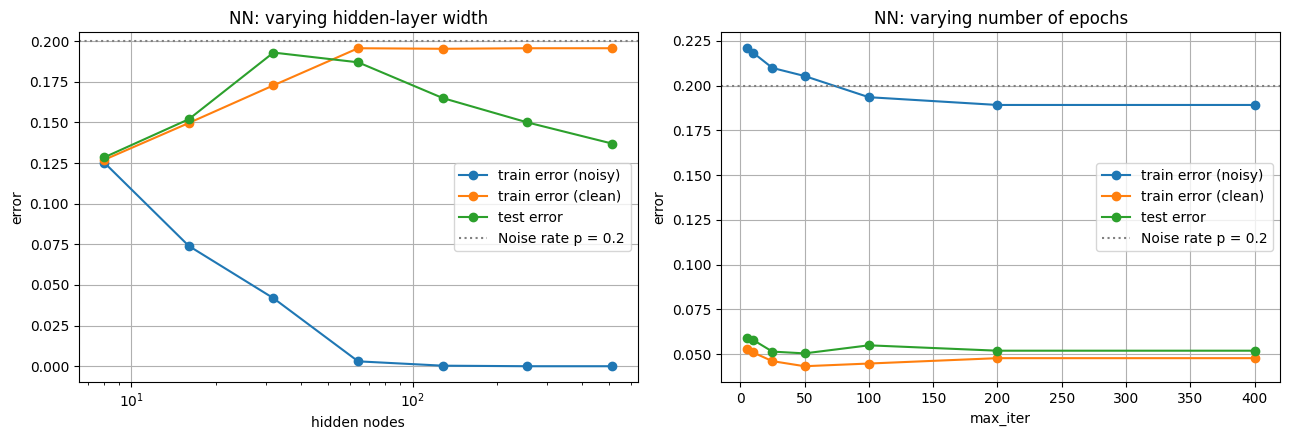

The best choice for tuned NN is {'hidden_layer_sizes': (32,), 'activation': 'relu', 'alpha': 1.0}, train_error=0.1892 and test_error=0.0520


In [14]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ax[0].semilogx(exp_nodes["n"], exp_nodes["train_error_noisy"], "o-", label="train error (noisy)")
ax[0].semilogx(exp_nodes["n"], exp_nodes["train_error_clean"], "o-", label="train error (clean)")
ax[0].semilogx(exp_nodes["n"], exp_nodes["test_error"], "o-", label="test error")
ax[0].axhline(p_flip, ls=":", color="grey", label=f"Noise rate p = {p_flip}")
ax[0].set(xlabel="hidden nodes", ylabel="error", title="NN: varying hidden-layer width")
ax[0].legend(); ax[0].grid(True)

ax[1].plot(exp_epochs["max_iter"], exp_epochs["train_error_noisy"], "o-", label="train error (noisy)")
ax[1].plot(exp_epochs["max_iter"], exp_epochs["train_error_clean"], "o-", label="train error (clean)")
ax[1].plot(exp_epochs["max_iter"], exp_epochs["test_error"], "o-", label="test error")
ax[1].axhline(p_flip, ls=":", color="grey", label=f"Noise rate p = {p_flip}")
ax[1].set(xlabel="max_iter", ylabel="error", title="NN: varying number of epochs")
ax[1].legend(); ax[1].grid(True)

plt.tight_layout(); plt.savefig("nn vary one.png", dpi=800, bbox_inches="tight"); plt.show()


final_nn = MLPClassifier(random_state=123, **best_nn)
final_nn.fit(X_train, y_train_noisy)
nn_train_error = 1 - final_nn.score(X_train, y_train_noisy)
nn_test_error = 1 - final_nn.score(X_test, y_test)
print(f"The best choice for tuned NN is {best_nn}, train_error={nn_train_error:.4f} and test_error={nn_test_error:.4f}")

               method  test_err    ci_low   ci_high  ci_halfwidth
0          Linear SVM    0.0695  0.058355  0.080645      0.011145
1  Gaussian SVM (RBF)    0.0285  0.021207  0.035793      0.007293
2      Neural Network    0.0520  0.042269  0.061731      0.009731


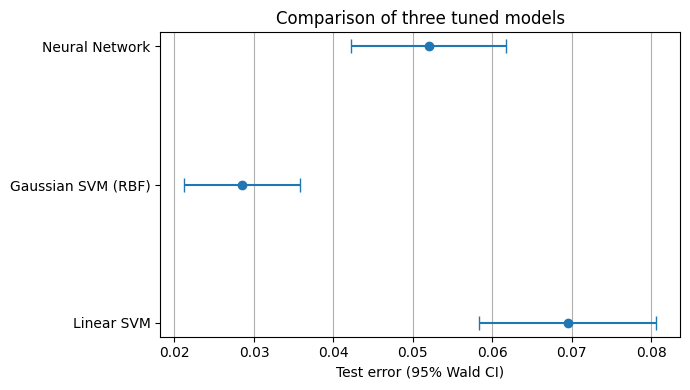

Pairwise CI overlap (True = NOT clearly distinguishable):
  Linear SVM           vs Gaussian SVM (RBF)  : overlap = False
  Linear SVM           vs Neural Network      : overlap = True
  Gaussian SVM (RBF)   vs Neural Network      : overlap = False


In [15]:
n_test = len(y_test)
z = 1.96

def wald_ci(error, n):
    half = z * np.sqrt(error * (1 - error) / n)
    return error - half, error + half

results = [('Linear SVM', lin_test_error), ('Gaussian SVM (RBF)', rbf_test_error), ('Neural Network', nn_test_error)]

comp = []
for name, err in results:
    lo, hi = wald_ci(err, n_test)
    comp.append({'method': name, 'test_err': err,
                 'ci_low': lo, 'ci_high': hi,
                 'ci_halfwidth': z*np.sqrt(err*(1-err)/n_test)})
comp = pd.DataFrame(comp); print(comp)

plt.figure(figsize=(7, 4))
ys = np.arange(len(comp))
plt.errorbar(comp['test_err'], ys, xerr=comp['ci_halfwidth'], fmt='o', capsize=5)
plt.yticks(ys, comp['method'])
plt.xlabel('Test error (95% Wald CI)')
plt.title('Comparison of three tuned models')
plt.grid(True, axis='x'); plt.tight_layout()
plt.savefig('part4 comparison.png', dpi=800, bbox_inches='tight'); plt.show()

# Pairwise overlap check (a crude significance check)
print('Pairwise CI overlap (True = NOT clearly distinguishable):')
for i in range(len(comp)):
    for j in range(i+1, len(comp)):
        a, b = comp.iloc[i], comp.iloc[j]
        overlap = not (a['ci_high'] < b['ci_low'] or b['ci_high'] < a['ci_low'])
        print(f"  {a['method']:20s} vs {b['method']:20s}: overlap = {overlap}")